## Creating Synthetic dataset

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Setting random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Configuration
NUM_RIDES = 10000
NUM_DRIVERS = 500
START_DATE = datetime(2024, 9, 1)
END_DATE = datetime(2024, 9, 30)

# Bangalore locations with coordinates (major areas)
LOCATIONS = {
    'Koramangala': (12.9352, 77.6245),
    'Indiranagar': (12.9716, 77.6412),
    'Whitefield': (12.9698, 77.7500),
    'Electronic City': (12.8456, 77.6603),
    'Jayanagar': (12.9250, 77.5838),
    'Marathahalli': (12.9591, 77.6974),
    'HSR Layout': (12.9116, 77.6473),
    'BTM Layout': (12.9166, 77.6101),
    'MG Road': (12.9750, 77.6067),
    'Malleshwaram': (13.0039, 77.5704),
    'Yelahanka': (13.1007, 77.5963),
    'Bannerghatta Road': (12.8889, 77.5958),
    'Sarjapur Road': (12.9010, 77.6874),
    'Bellandur': (12.9266, 77.6780),
    'Hebbal': (13.0358, 77.5970)
}

LOCATION_NAMES = list(LOCATIONS.keys())

# Generating timestamps with realistic patterns
def generate_timestamp():
    """Generate timestamp with peak hour patterns"""
    days = (END_DATE - START_DATE).days
    day = random.randint(0, days)
    date = START_DATE + timedelta(days=day)
    
    # Peak hours: 8-10 AM and 6-9 PM (higher probability)
    hour_weights = [1, 1, 1, 1, 1, 2, 4, 8, 10, 8, 4, 3, 
                   3, 3, 3, 4, 5, 8, 10, 9, 6, 4, 2, 1]
    hour = random.choices(range(24), weights=hour_weights)[0]
    minute = random.randint(0, 59)
    
    return date.replace(hour=hour, minute=minute, second=random.randint(0, 59))

# Generating Driver Data
print("Generating driver data...")
drivers_data = []
for i in range(1, NUM_DRIVERS + 1):
    driver = {
        'driver_id': f'DRV{i:05d}',
        'driver_name': f'Driver_{i}',
        'phone': f'+91{random.randint(7000000000, 9999999999)}',
        'vehicle_type': random.choices(['Sedan', 'Hatchback', 'SUV'], weights=[0.5, 0.4, 0.1])[0],
        'registration_date': (START_DATE - timedelta(days=random.randint(30, 730))).strftime('%Y-%m-%d'),
        'total_trips_completed': random.randint(50, 5000),
        'average_rating': round(random.uniform(3.5, 5.0), 2),
        'home_location': random.choice(LOCATION_NAMES)
    }
    drivers_data.append(driver)

drivers_df = pd.DataFrame(drivers_data)

# Generating Ride Data
print("Generating ride data...")
rides_data = []
driver_ids = drivers_df['driver_id'].tolist()

for i in range(1, NUM_RIDES + 1):
    pickup_location = random.choice(LOCATION_NAMES)
    
    # Drop location more likely to be different but sometimes same (intra-area rides)
    if random.random() < 0.85:
        drop_location = random.choice([loc for loc in LOCATION_NAMES if loc != pickup_location])
    else:
        drop_location = pickup_location
    
    pickup_coords = LOCATIONS[pickup_location]
    drop_coords = LOCATIONS[drop_location]
    
    # Calculate approximate distance (Euclidean distance scaled to km)
    distance_km = round(np.sqrt((pickup_coords[0] - drop_coords[0])**2 + 
                                (pickup_coords[1] - drop_coords[1])**2) * 100, 2)
    distance_km = max(distance_km, 1.0)  # Minimum 1 km
    
    # Base fare calculation
    base_fare = 50
    per_km_fare = 12
    estimated_fare = base_fare + (distance_km * per_km_fare)
    
    # Surge multiplier (higher during peak hours)
    request_time = generate_timestamp()
    hour = request_time.hour
    if hour in [8, 9, 18, 19, 20]:
        surge_multiplier = round(random.uniform(1.0, 2.0), 2)
    else:
        surge_multiplier = 1.0
    
    final_fare = round(estimated_fare * surge_multiplier, 2)
    
    # Ride status and driver assignment
    status_weights = [0.75, 0.15, 0.10]  # completed, cancelled_by_driver, cancelled_by_rider
    ride_status = random.choices(['completed', 'cancelled_by_driver', 'cancelled_by_rider'], 
                                 weights=status_weights)[0]
    
    assigned_driver = random.choice(driver_ids) if ride_status != 'cancelled_by_rider' else None
    
    # Trip duration (only for completed rides)
    if ride_status == 'completed':
        trip_duration_mins = int(distance_km * random.uniform(3, 5))  # 3-5 mins per km
        pickup_time = request_time + timedelta(minutes=random.randint(2, 15))
        drop_time = pickup_time + timedelta(minutes=trip_duration_mins)
        rider_rating = round(random.uniform(3.0, 5.0), 1)
        driver_rating = round(random.uniform(3.5, 5.0), 1)
    else:
        trip_duration_mins = 0
        pickup_time = None
        drop_time = None
        rider_rating = None
        driver_rating = None
        final_fare = 0
    
    # Weather condition (affects demand)
    weather = random.choices(['Clear', 'Rainy', 'Cloudy'], weights=[0.6, 0.2, 0.2])[0]
    
    ride = {
        'ride_id': f'RIDE{i:06d}',
        'request_time': request_time.strftime('%Y-%m-%d %H:%M:%S'),
        'pickup_location': pickup_location,
        'drop_location': drop_location,
        'pickup_lat': pickup_coords[0] + random.uniform(-0.01, 0.01),
        'pickup_lon': pickup_coords[1] + random.uniform(-0.01, 0.01),
        'drop_lat': drop_coords[0] + random.uniform(-0.01, 0.01),
        'drop_lon': drop_coords[1] + random.uniform(-0.01, 0.01),
        'distance_km': distance_km,
        'estimated_fare': estimated_fare,
        'surge_multiplier': surge_multiplier,
        'final_fare': final_fare,
        'rider_id': f'USR{random.randint(1, 3000):05d}',
        'driver_id': assigned_driver,
        'ride_status': ride_status,
        'pickup_time': pickup_time.strftime('%Y-%m-%d %H:%M:%S') if pickup_time else None,
        'drop_time': drop_time.strftime('%Y-%m-%d %H:%M:%S') if drop_time else None,
        'trip_duration_mins': trip_duration_mins,
        'rider_rating': rider_rating,
        'driver_rating': driver_rating,
        'payment_method': random.choice(['Cash', 'UPI', 'Card', 'Wallet']),
        'weather': weather,
        'day_of_week': request_time.strftime('%A'),
        'is_weekend': request_time.weekday() >= 5
    }
    rides_data.append(ride)

rides_df = pd.DataFrame(rides_data)

# Generate Driver Availability Data (sample)
print("Generating driver availability data...")
availability_data = []
sample_dates = pd.date_range(START_DATE, END_DATE, freq='D')

for date in sample_dates:
    for _ in range(50):  # 50 availability snapshots per day
        timestamp = date + timedelta(hours=random.randint(0, 23), 
                                    minutes=random.randint(0, 59))
        driver = random.choice(driver_ids)
        location = random.choice(LOCATION_NAMES)
        
        availability = {
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'driver_id': driver,
            'is_available': random.choice([True, False]),
            'current_location': location,
            'current_lat': LOCATIONS[location][0] + random.uniform(-0.01, 0.01),
            'current_lon': LOCATIONS[location][1] + random.uniform(-0.01, 0.01)
        }
        availability_data.append(availability)

availability_df = pd.DataFrame(availability_data)

# Save to CSV files
print("Saving data to CSV files...")
drivers_df.to_csv(r'C:\Users\shrav\Desktop\Syntheticdata\drivers_data.csv', index=False)
rides_df.to_csv(r'C:\Users\shrav\Desktop\Syntheticdata\rides_data.csv', index=False)
availability_df.to_csv(r'C:\Users\shrav\Desktop\Syntheticdata\driver_availability.csv', index=False)

print(f"\nData generation complete!")
print(f"\nDataset Summary:")
print(f"   - Drivers: {len(drivers_df):,} records")
print(f"   - Rides: {len(rides_df):,} records")
print(f"   - Driver Availability: {len(availability_df):,} snapshots")
print(f"\n Files created:")
print(f"   - drivers_data.csv")
print(f"   - rides_data.csv")
print(f"   - driver_availability.csv")

print(f"\n Ride Status Distribution:")
print(rides_df['ride_status'].value_counts())

print(f"\n Revenue Metrics:")
print(f"   Total Revenue: ₹{rides_df[rides_df['ride_status']=='completed']['final_fare'].sum():,.2f}")
print(f"   Average Fare: ₹{rides_df[rides_df['ride_status']=='completed']['final_fare'].mean():.2f}")
print(f"   Cancellation Rate: {(rides_df['ride_status']!='completed').sum()/len(rides_df)*100:.1f}%")

Generating driver data...
Generating ride data...
Generating driver availability data...
Saving data to CSV files...

Data generation complete!

Dataset Summary:
   - Drivers: 500 records
   - Rides: 10,000 records
   - Driver Availability: 1,500 snapshots

 Files created:
   - drivers_data.csv
   - rides_data.csv
   - driver_availability.csv

 Ride Status Distribution:
ride_status
completed              7486
cancelled_by_driver    1509
cancelled_by_rider     1005
Name: count, dtype: int64

 Revenue Metrics:
   Total Revenue: ₹1,406,026.63
   Average Fare: ₹187.82
   Cancellation Rate: 25.1%


## Exploratory Data Analysis 

Step1 -> Laoding the dataset<br>
Step2 <br>
-> Convert time dateColums . Converts time-related columns to proper datetime objects for analysis (so we can                extract hours, dates, weekdays, etc.)<br>
-> hour → Extracts the request hour.<br>
   date → Extracts only the date part.<br>
   day_name → Extracts weekday name (Monday, Tuesday, etc.)<br>
Critical Business Problems I've Identified:<br>
25.1% Cancellation Rate - That's HUGE! ₹350K+ potential revenue lost<br>
Driver cancellations (15.1%) are higher than rider cancellations - why?<br>
Surge pricing adds ₹2.5L extra - but is it optimized?<br>
Earnings inequality - Top driver earns 2x the average (₹5,653 vs ₹2,812)<br>


In [49]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime 
#step1
drivers = pd.read_csv('drivers_data.csv')
rides=pd.read_csv('rides_data.csv')
availability=pd.read_csv('driver_availability.csv')
print("Data loaded successfully!\n")
#step2
rides['request_time'] = pd.to_datetime(rides['request_time'])
rides['pickup_time'] = pd.to_datetime(rides['pickup_time'])
rides['drop_time'] = pd.to_datetime(rides['drop_time'])
availability['timestamp'] = pd.to_datetime(availability['timestamp'])
rides['hour'] = rides['request_time'].dt.hour
rides['date'] = rides['request_time'].dt.date
rides['day_name'] = rides['request_time'].dt.day_name()
print("="*70)
print("                    EXPLORATORY DATA ANALYSIS")
print("="*70)
print("\n 1. KEY BUSINESS METRICS")
print("-"*70)
completed_rides = rides[rides['ride_status'] == 'completed']
total_revenue = completed_rides['final_fare'].sum()
avg_fare = completed_rides['final_fare'].mean()
cancellation_rate = (len(rides) - len(completed_rides)) / len(rides) * 100
print(f"Total Rides Requested: {len(rides):,}")
print(f"Completed Rides: {len(completed_rides):,}")
print(f"Cancellation Rate: {cancellation_rate:.1f}%")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Fare: ₹{avg_fare:.2f}")
print(f"Average Trip Duration: {completed_rides['trip_duration_mins'].mean():.1f} mins")
print(f"Average Distance: {completed_rides['distance_km'].mean():.2f} km")

print("\n\n 2. CANCELLATION Analysis")
print("-"*70)

cancellation_stats = rides['ride_status'].value_counts()
print(cancellation_stats)
print(f"\nDriver Cancellation Rate: {(cancellation_stats.get('cancelled_by_driver', 0) / len(rides) * 100):.1f}%")
print(f"Rider Cancellation Rate: {(cancellation_stats.get('cancelled_by_rider', 0) / len(rides) * 100):.1f}%")

print("\n\n 3. PEAK HOURS DEMAND ANALYSIS")
print("-"*70)

hourly_demand = rides.groupby('hour').size().reset_index(name='ride_count')
hourly_demand['percentage'] = (hourly_demand['ride_count'] / len(rides) * 100).round(2)

print("\nTop 5 Peak Hours:")
top_hours = hourly_demand.nlargest(5, 'ride_count')
for _, row in top_hours.iterrows():
    hour = int(row['hour'])
    time_str = f"{hour:02d}:00 - {hour+1:02d}:00"
    print(f"  {time_str}: {row['ride_count']:,} rides ({row['percentage']:.1f}%)")


print("\n\n 4. LOCATION HOTSPOTS")
print("-"*70)

print("\nTop 5 Pickup Locations:")
top_pickups = rides['pickup_location'].value_counts().head(5)
for loc, count in top_pickups.items():
    print(f"  {loc}: {count:,} rides ({count/len(rides)*100:.1f}%)")

print("\nTop 5 Drop Locations:")
top_drops = rides['drop_location'].value_counts().head(5)
for loc, count in top_drops.items():
    print(f"  {loc}: {count:,} rides ({count/len(rides)*100:.1f}%)")

print("\n\n 5. REVENUE ANALYSIS")
print("-"*70)

daily_revenue = completed_rides.groupby('date')['final_fare'].sum()
print(f"Average Daily Revenue: ₹{daily_revenue.mean():,.2f}")
print(f"Highest Daily Revenue: ₹{daily_revenue.max():,.2f}")
print(f"Lowest Daily Revenue: ₹{daily_revenue.min():,.2f}")

# Surge analysis
surge_rides = completed_rides[completed_rides['surge_multiplier'] > 1.0]
print(f"\nRides with Surge Pricing: {len(surge_rides):,} ({len(surge_rides)/len(completed_rides)*100:.1f}%)")
print(f"Additional Revenue from Surge: ₹{(surge_rides['final_fare'].sum() - surge_rides['estimated_fare'].sum()):,.2f}")

print("\n\n 6. DRIVER METRICS")
print("-"*70)

driver_trips = completed_rides.groupby('driver_id').agg({
    'ride_id': 'count',
    'final_fare': 'sum',
    'driver_rating': 'mean'
}).rename(columns={'ride_id': 'trips', 'final_fare': 'earnings'})

print(f"Average Trips per Driver: {driver_trips['trips'].mean():.1f}")
print(f"Average Driver Rating: {completed_rides['driver_rating'].mean():.2f}")
print(f"Average Earnings per Driver: ₹{driver_trips['earnings'].mean():,.2f}")

print("\nTop 5 Drivers by Earnings:")
top_drivers = driver_trips.nlargest(5, 'earnings')
for driver_id, row in top_drivers.iterrows():
    print(f"  {driver_id}: ₹{row['earnings']:,.2f} ({int(row['trips'])} trips, {row['driver_rating']:.2f}★)") 

print("\n\n 7. WEEKLY PATTERNS")
print("-"*70)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern = rides.groupby('day_name').agg({
    'ride_id': 'count',
    'final_fare': lambda x: x[x > 0].sum()
}).reindex(day_order)

print("\nRides by Day:")
for day, row in weekly_pattern.iterrows():
    is_weekend = "🎉 " if day in ['Saturday', 'Sunday'] else "   "
    print(f"{is_weekend}{day}: {int(row['ride_id']):,} rides, ₹{row['final_fare']:,.2f} revenue")

print("\n\n 8. WEATHER IMPACT")
print("-"*70)

weather_impact = rides.groupby('weather').agg({
    'ride_id': 'count',
    'final_fare': lambda x: x[x > 0].sum()
}).sort_values('ride_id', ascending=False)

print("\nDemand by Weather:")
for weather, row in weather_impact.iterrows():
    print(f"  {weather}: {int(row['ride_id']):,} rides, ₹{row['final_fare']:,.2f} revenue")

print("\n\n" + "="*70)
print("                      KEY INSIGHTS DISCOVERED")
print("="*70)

print("\n1. DEMAND PATTERNS:")
peak_hour = hourly_demand.loc[hourly_demand['ride_count'].idxmax(), 'hour']
print(f"   • Peak demand hour: {int(peak_hour):02d}:00")
print(f"   • Weekend vs Weekday: {'Higher on weekends' if weekly_pattern.loc['Saturday':'Sunday', 'ride_id'].sum() > weekly_pattern.loc['Monday':'Friday', 'ride_id'].mean() * 2 else 'Higher on weekdays'}")

print("\n2. CANCELLATION CHALLENGE:")
print(f"   • {cancellation_rate:.1f}% rides cancelled - significant revenue loss")
print(f"   • Driver cancellations: {cancellation_stats.get('cancelled_by_driver', 0):,} rides")

print("\n3. REVENUE OPPORTUNITIES:")
print(f"   • Surge pricing adds ₹{(surge_rides['final_fare'].sum() - surge_rides['estimated_fare'].sum()):,.0f} extra revenue")
print(f"   • Top location: {top_pickups.index[0]} with {top_pickups.iloc[0]:,} pickups")

print("\n4. DRIVER INSIGHTS:")
print(f"   • High variance in driver earnings (top driver earns ₹{top_drivers['earnings'].iloc[0]:,.0f})")
print(f"   • Average driver rating: {completed_rides['driver_rating'].mean():.2f}/5.0")

print("\n" + "="*70)
print(" EDA Complete!")
print("="*70)

Data loaded successfully!

                    EXPLORATORY DATA ANALYSIS

 1. KEY BUSINESS METRICS
----------------------------------------------------------------------
Total Rides Requested: 10,000
Completed Rides: 7,486
Cancellation Rate: 25.1%
Total Revenue: ₹1,406,026.63
Average Fare: ₹187.82
Average Trip Duration: 34.3 mins
Average Distance: 8.69 km


 2. CANCELLATION Analysis
----------------------------------------------------------------------
ride_status
completed              7486
cancelled_by_driver    1509
cancelled_by_rider     1005
Name: count, dtype: int64

Driver Cancellation Rate: 15.1%
Rider Cancellation Rate: 10.1%


 3. PEAK HOURS DEMAND ANALYSIS
----------------------------------------------------------------------

Top 5 Peak Hours:
  08:00 - 09:00: 1,041.0 rides (10.4%)
  18:00 - 19:00: 981.0 rides (9.8%)
  19:00 - 20:00: 899.0 rides (9.0%)
  07:00 - 08:00: 798.0 rides (8.0%)
  17:00 - 18:00: 758.0 rides (7.6%)


 4. LOCATION HOTSPOTS
---------------------------

## Data Visualization

Creating visualizations...
 Saved: viz1_hourly_demand.png


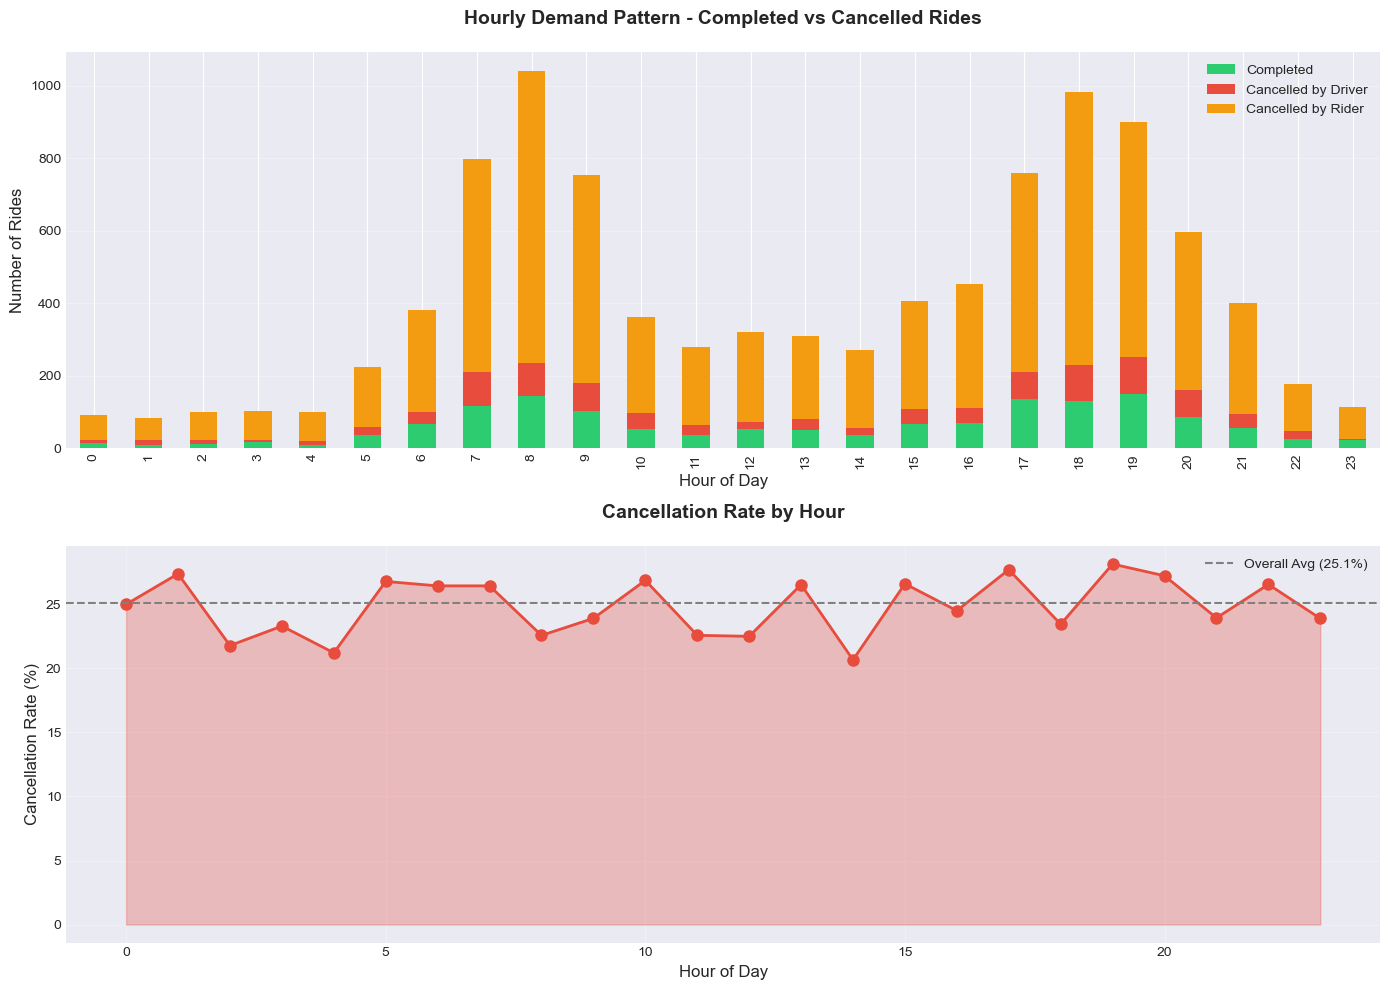

 Saved: viz2_location_analysis.png


<Figure size 640x480 with 0 Axes>

 Saved: viz3_revenue_analysis.png


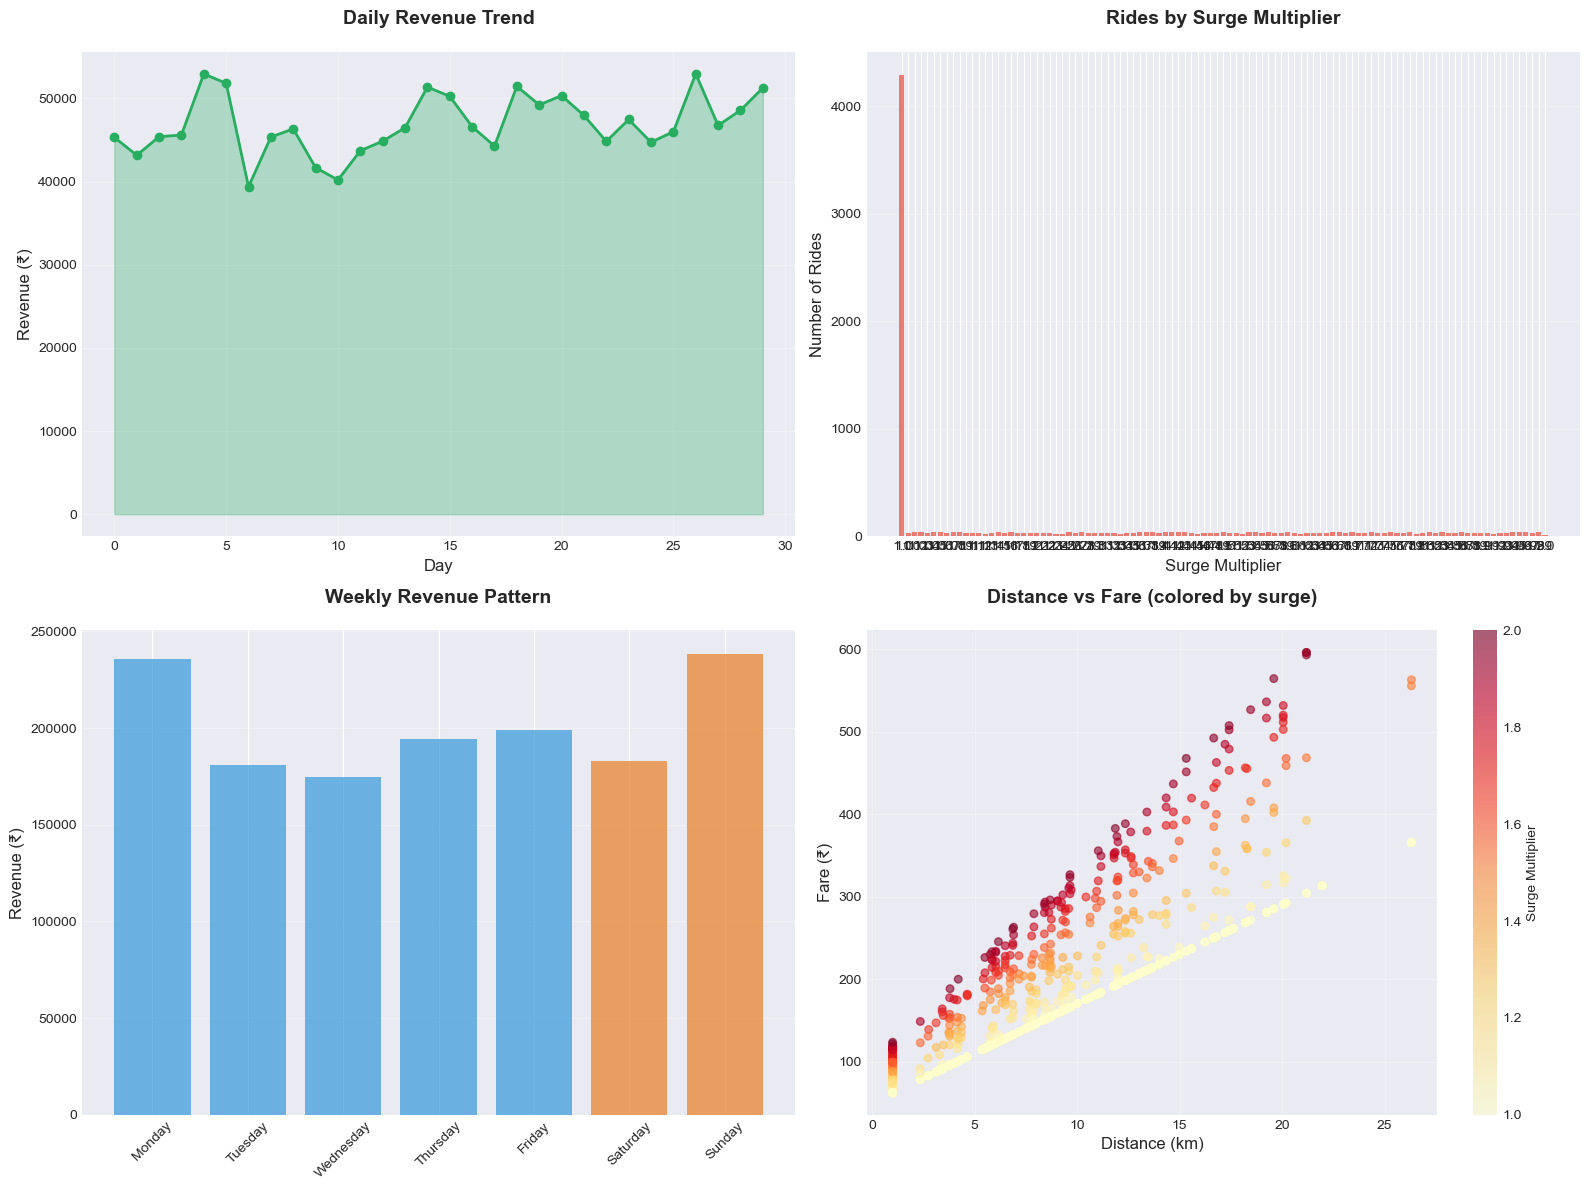

 Saved: viz4_driver_performance.png


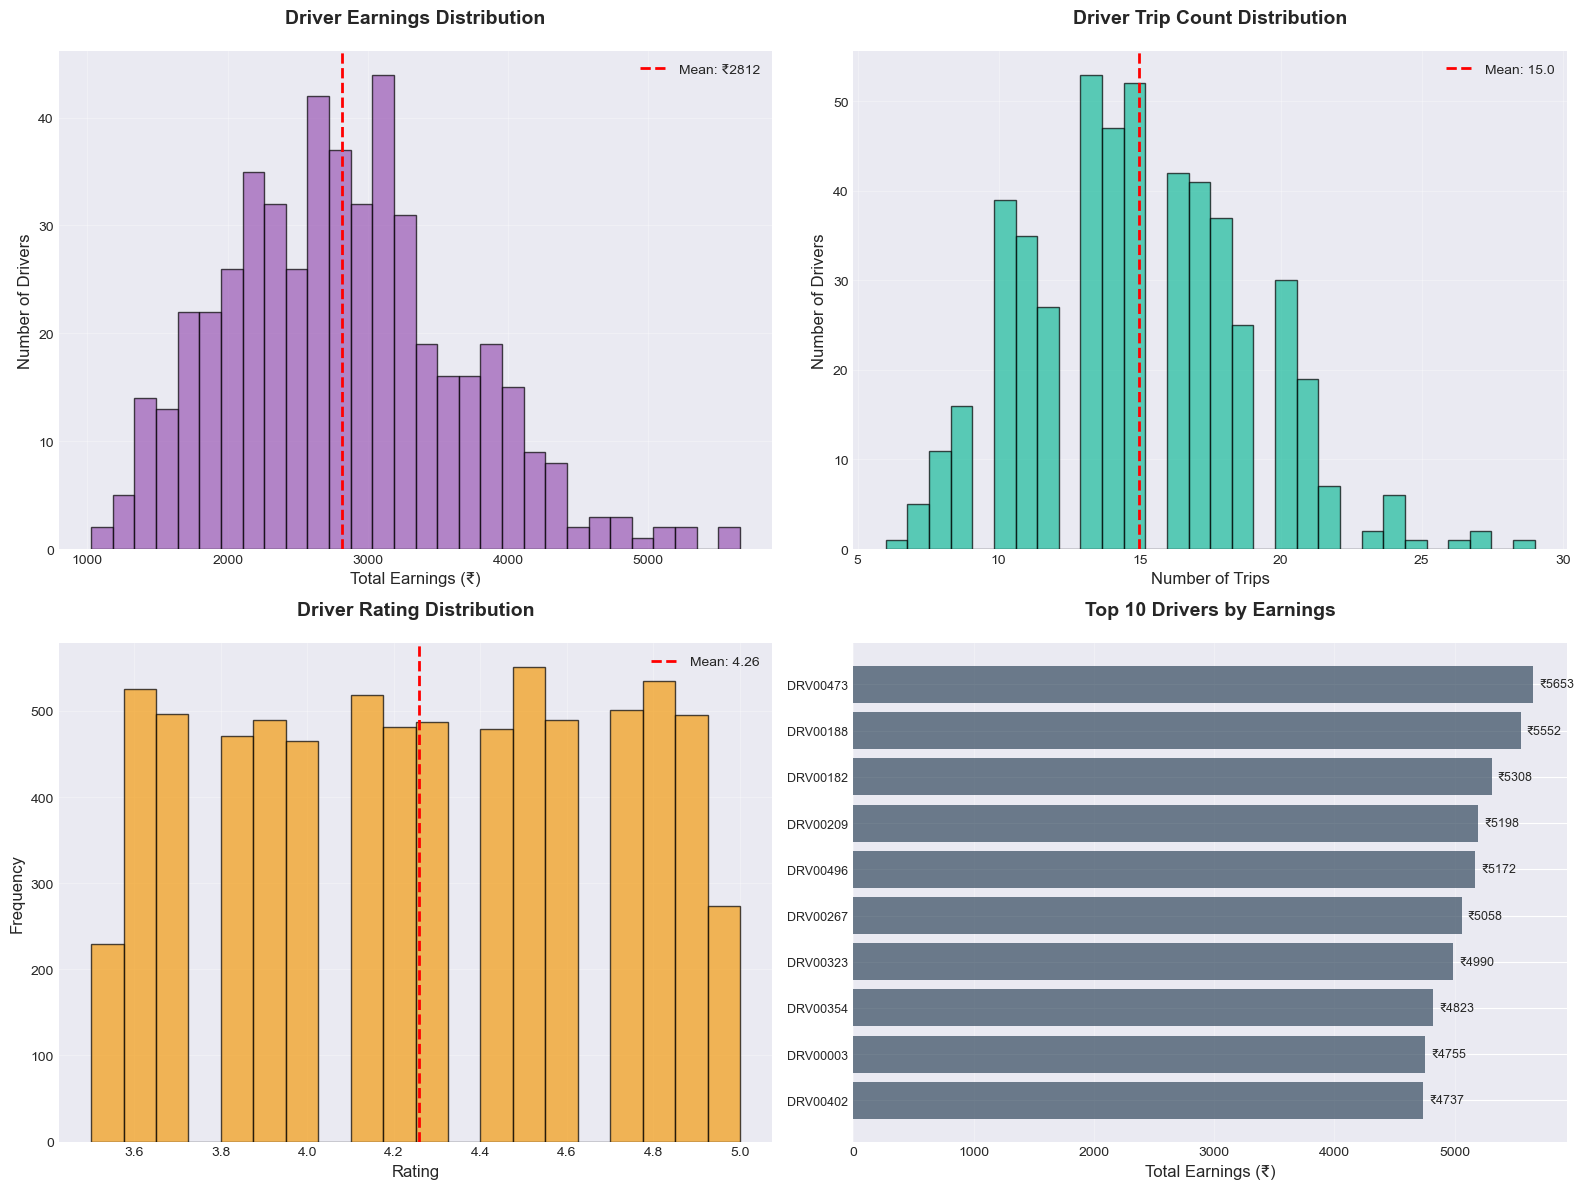

Saved: viz5_cancellation_analysis.png


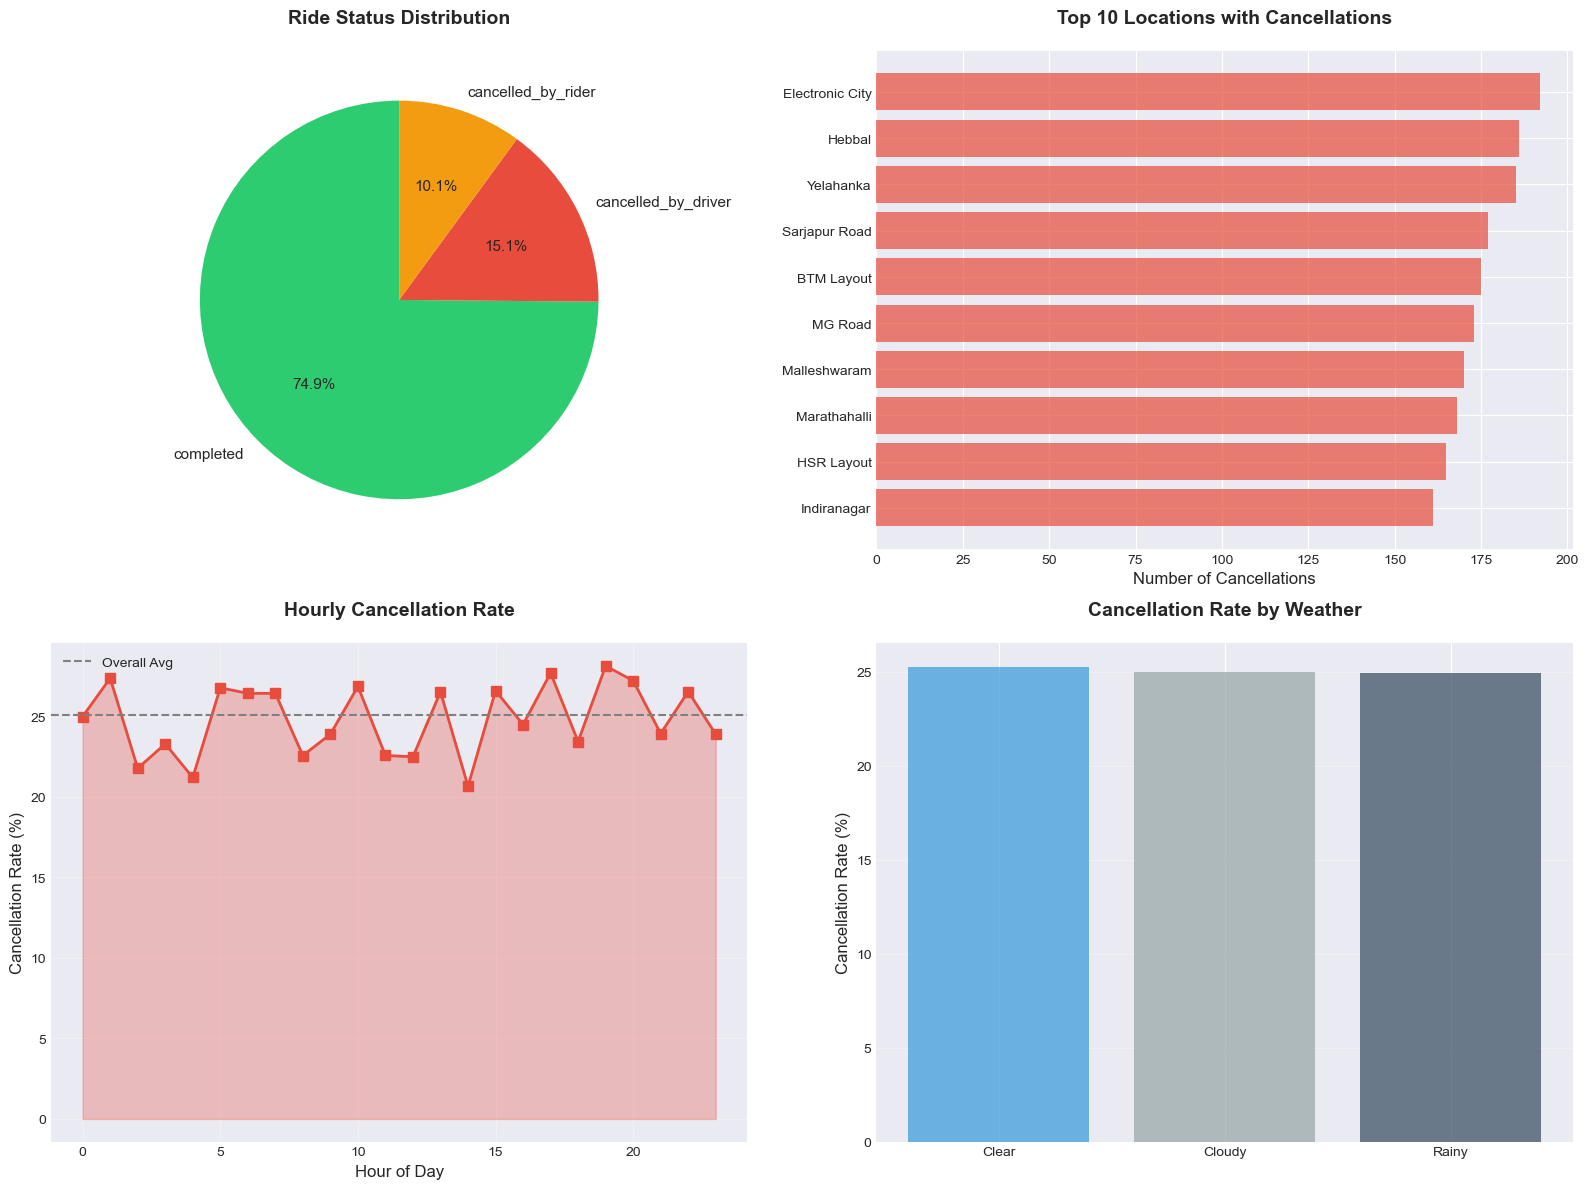


 ALL VISUALIZATIONS CREATED SUCCESSFULLY!

Generated files:
   viz1_hourly_demand.png
   viz2_location_analysis.png
   viz3_revenue_analysis.png
   viz4_driver_performance.png
   viz5_cancellation_analysis.png


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')
print("Creating visualizations...")
print("="*70)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Demand by hour
hourly_data = rides.groupby(['hour', 'ride_status']).size().unstack(fill_value=0)
hourly_data.plot(kind='bar', stacked=True, ax=axes[0], 
                 color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Hourly Demand Pattern - Completed vs Cancelled Rides', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].legend(['Completed', 'Cancelled by Driver', 'Cancelled by Rider'], 
               loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
# Cancellation rate by hour
cancel_rate = rides.groupby('hour').apply(
    lambda x: (x['ride_status'] != 'completed').sum() / len(x) * 100
)
axes[1].plot(cancel_rate.index, cancel_rate.values, marker='o', 
             linewidth=2, markersize=8, color='#e74c3c')
axes[1].axhline(y=25.1, color='gray', linestyle='--', label='Overall Avg (25.1%)')
axes[1].fill_between(cancel_rate.index, cancel_rate.values, alpha=0.3, color='#e74c3c')
axes[1].set_title('Cancellation Rate by Hour', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz1_hourly_demand.png', dpi=300, bbox_inches='tight')
print(" Saved: viz1_hourly_demand.png")
plt.show()

# Top pickup locations
top_pickups = rides['pickup_location'].value_counts().head(10)
axes[0].barh(range(len(top_pickups)), top_pickups.values, color='#3498db')
axes[0].set_yticks(range(len(top_pickups)))
axes[0].set_yticklabels(top_pickups.index)
axes[0].set_xlabel('Number of Rides', fontsize=12)
axes[0].set_title('Top 10 Pickup Locations', fontsize=14, fontweight='bold', pad=20)
axes[0].invert_yaxis()

# Add value labels
for i, v in enumerate(top_pickups.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=10)
top_drops = rides['drop_location'].value_counts().head(10)
axes[1].barh(range(len(top_drops)), top_drops.values, color='#e67e22')
axes[1].set_yticks(range(len(top_drops)))
axes[1].set_yticklabels(top_drops.index)
axes[1].set_xlabel('Number of Rides', fontsize=12)
axes[1].set_title('Top 10 Drop Locations', fontsize=14, fontweight='bold', pad=20)
axes[1].invert_yaxis()

# Add value labels
for i, v in enumerate(top_drops.values):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('viz2_location_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: viz2_location_analysis.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daily revenue trend
daily_revenue = completed_rides.groupby('date')['final_fare'].sum()
axes[0, 0].plot(range(len(daily_revenue)), daily_revenue.values, 
                marker='o', linewidth=2, color='#27ae60')
axes[0, 0].fill_between(range(len(daily_revenue)), daily_revenue.values, 
                         alpha=0.3, color='#27ae60')
axes[0, 0].set_title('Daily Revenue Trend', fontsize=14, fontweight='bold', pad=20)
axes[0, 0].set_xlabel('Day', fontsize=12)
axes[0, 0].set_ylabel('Revenue (₹)', fontsize=12)
axes[0, 0].grid(alpha=0.3)

# Surge pricing impact
surge_data = completed_rides.groupby('surge_multiplier').size()
axes[0, 1].bar(surge_data.index.astype(str), surge_data.values, color='#e74c3c', alpha=0.7)
axes[0, 1].set_title('Rides by Surge Multiplier', fontsize=14, fontweight='bold', pad=20)
axes[0, 1].set_xlabel('Surge Multiplier', fontsize=12)
axes[0, 1].set_ylabel('Number of Rides', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Weekly revenue pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_revenue = completed_rides.groupby('day_name')['final_fare'].sum().reindex(day_order)
colors = ['#3498db' if day not in ['Saturday', 'Sunday'] else '#e67e22' for day in day_order]
axes[1, 0].bar(range(len(weekly_revenue)), weekly_revenue.values, color=colors, alpha=0.7)
axes[1, 0].set_xticks(range(len(day_order)))
axes[1, 0].set_xticklabels(day_order, rotation=45)
axes[1, 0].set_title('Weekly Revenue Pattern', fontsize=14, fontweight='bold', pad=20)
axes[1, 0].set_ylabel('Revenue (₹)', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Distance vs Fare scatter
sample_rides = completed_rides.sample(min(1000, len(completed_rides)))
scatter = axes[1, 1].scatter(sample_rides['distance_km'], sample_rides['final_fare'],
                             c=sample_rides['surge_multiplier'], cmap='YlOrRd', 
                             alpha=0.6, s=30)
axes[1, 1].set_title('Distance vs Fare (colored by surge)', 
                     fontsize=14, fontweight='bold', pad=20)
axes[1, 1].set_xlabel('Distance (km)', fontsize=12)
axes[1, 1].set_ylabel('Fare (₹)', fontsize=12)
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Surge Multiplier')

plt.tight_layout()
plt.savefig('viz3_revenue_analysis.png', dpi=300, bbox_inches='tight')
print(" Saved: viz3_revenue_analysis.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Driver earnings distribution
driver_earnings = completed_rides.groupby('driver_id')['final_fare'].sum()
axes[0, 0].hist(driver_earnings.values, bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(driver_earnings.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: ₹{driver_earnings.mean():.0f}')
axes[0, 0].set_title('Driver Earnings Distribution', fontsize=14, fontweight='bold', pad=20)
axes[0, 0].set_xlabel('Total Earnings (₹)', fontsize=12)
axes[0, 0].set_ylabel('Number of Drivers', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Driver trips distribution
driver_trips = completed_rides.groupby('driver_id').size()
axes[0, 1].hist(driver_trips.values, bins=30, color='#1abc9c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(driver_trips.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {driver_trips.mean():.1f}')
axes[0, 1].set_title('Driver Trip Count Distribution', fontsize=14, fontweight='bold', pad=20)
axes[0, 1].set_xlabel('Number of Trips', fontsize=12)
axes[0, 1].set_ylabel('Number of Drivers', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(completed_rides['driver_rating'].dropna(), bins=20, 
                color='#f39c12', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(completed_rides['driver_rating'].mean(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Mean: {completed_rides["driver_rating"].mean():.2f}')
axes[1, 0].set_title('Driver Rating Distribution', fontsize=14, fontweight='bold', pad=20)
axes[1, 0].set_xlabel('Rating', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Top 10 drivers by earnings
top_drivers = completed_rides.groupby('driver_id')['final_fare'].sum().nlargest(10)
axes[1, 1].barh(range(len(top_drivers)), top_drivers.values, color='#34495e', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_drivers)))
axes[1, 1].set_yticklabels(top_drivers.index, fontsize=9)
axes[1, 1].set_title('Top 10 Drivers by Earnings', fontsize=14, fontweight='bold', pad=20)
axes[1, 1].set_xlabel('Total Earnings (₹)', fontsize=12)
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_drivers.values):
    axes[1, 1].text(v + 50, i, f'₹{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz4_driver_performance.png', dpi=300, bbox_inches='tight')
print(" Saved: viz4_driver_performance.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cancellation by status
cancel_counts = rides['ride_status'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c', '#f39c12']
axes[0, 0].pie(cancel_counts.values, labels=cancel_counts.index, autopct='%1.1f%%',
               colors=colors_pie, startangle=90, textprops={'fontsize': 11})
axes[0, 0].set_title('Ride Status Distribution', fontsize=14, fontweight='bold', pad=20)

# Cancellation by location
cancel_by_location = rides[rides['ride_status'] != 'completed'].groupby('pickup_location').size().nlargest(10)
axes[0, 1].barh(range(len(cancel_by_location)), cancel_by_location.values, color='#e74c3c', alpha=0.7)
axes[0, 1].set_yticks(range(len(cancel_by_location)))
axes[0, 1].set_yticklabels(cancel_by_location.index, fontsize=10)
axes[0, 1].set_title('Top 10 Locations with Cancellations', fontsize=14, fontweight='bold', pad=20)
axes[0, 1].set_xlabel('Number of Cancellations', fontsize=12)
axes[0, 1].invert_yaxis()

# Cancellation by hour
hourly_cancel = rides.groupby(['hour', 'ride_status']).size().unstack(fill_value=0)
cancel_rate_hourly = (hourly_cancel['cancelled_by_driver'] + hourly_cancel['cancelled_by_rider']) / hourly_cancel.sum(axis=1) * 100
axes[1, 0].plot(cancel_rate_hourly.index, cancel_rate_hourly.values, 
                marker='s', linewidth=2, color='#e74c3c', markersize=7)
axes[1, 0].fill_between(cancel_rate_hourly.index, cancel_rate_hourly.values, alpha=0.3, color='#e74c3c')
axes[1, 0].axhline(y=25.1, color='gray', linestyle='--', linewidth=1.5, label='Overall Avg')
axes[1, 0].set_title('Hourly Cancellation Rate', fontsize=14, fontweight='bold', pad=20)
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Weather impact on cancellations
weather_cancel = rides.groupby('weather').apply(
    lambda x: (x['ride_status'] != 'completed').sum() / len(x) * 100
)
axes[1, 1].bar(weather_cancel.index, weather_cancel.values, 
               color=['#3498db', '#95a5a6', '#34495e'], alpha=0.7)
axes[1, 1].set_title('Cancellation Rate by Weather', fontsize=14, fontweight='bold', pad=20)
axes[1, 1].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz5_cancellation_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: viz5_cancellation_analysis.png")
plt.show()

print("\n" + "="*70)
print(" ALL VISUALIZATIONS CREATED SUCCESSFULLY!")
print("="*70)
print("\nGenerated files:")
print("   viz1_hourly_demand.png")
print("   viz2_location_analysis.png")
print("   viz3_revenue_analysis.png")
print("   viz4_driver_performance.png")
print("   viz5_cancellation_analysis.png")
print("="*70)


# Setting up Sql Database

In [40]:
import pandas as pd
import sqlite3
from datetime import datetime
print("="*70)
print("                       CREATING SQL DATABASE")
print("="*70)
conn = sqlite3.connect('namma_yatri.db')
cursor = conn.cursor()
print("\n Database connection established: namma_yatri.db")

print("\n Loading CSV files...")
drivers_df = pd.read_csv('drivers_data.csv')
rides_df = pd.read_csv('rides_data.csv')
availability_df = pd.read_csv('driver_availability.csv')

print(f"   • Drivers: {len(drivers_df):,} records")
print(f"   • Rides: {len(rides_df):,} records")
print(f"   • Availability: {len(availability_df):,} records")

print("\n  Creating database schema...")

# Drop existing tables if they exist
cursor.execute("DROP TABLE IF EXISTS rides")
cursor.execute("DROP TABLE IF EXISTS drivers")
cursor.execute("DROP TABLE IF EXISTS driver_availability")
cursor.execute("DROP TABLE IF EXISTS locations")
cursor.execute("DROP TABLE IF EXISTS riders")

cursor.execute("""
CREATE TABLE drivers (
    driver_id TEXT PRIMARY KEY,
    driver_name TEXT NOT NULL,
    phone TEXT,
    vehicle_type TEXT,
    registration_date DATE,
    total_trips_completed INTEGER,
    average_rating REAL,
    home_location TEXT
)
""")
print("     Created table: drivers")

cursor.execute("""
CREATE TABLE riders (
    rider_id TEXT PRIMARY KEY,
    total_rides INTEGER DEFAULT 0,
    average_rating REAL
)
""")
print("     Created table: riders")

cursor.execute("""
CREATE TABLE locations (
    location_name TEXT PRIMARY KEY,
    latitude REAL,
    longitude REAL,
    location_type TEXT
)
""")
print("     Created table: locations")

cursor.execute("""
CREATE TABLE rides (
    ride_id TEXT PRIMARY KEY,
    request_time TIMESTAMP NOT NULL,
    pickup_location TEXT,
    drop_location TEXT,
    pickup_lat REAL,
    pickup_lon REAL,
    drop_lat REAL,
    drop_lon REAL,
    distance_km REAL,
    estimated_fare REAL,
    surge_multiplier REAL DEFAULT 1.0,
    final_fare REAL,
    rider_id TEXT,
    driver_id TEXT,
    ride_status TEXT CHECK(ride_status IN ('completed', 'cancelled_by_driver', 'cancelled_by_rider')),
    pickup_time TIMESTAMP,
    drop_time TIMESTAMP,
    trip_duration_mins INTEGER,
    rider_rating REAL,
    driver_rating REAL,
    payment_method TEXT,
    weather TEXT,
    day_of_week TEXT,
    is_weekend BOOLEAN,
    FOREIGN KEY (driver_id) REFERENCES drivers(driver_id),
    FOREIGN KEY (rider_id) REFERENCES riders(rider_id),
    FOREIGN KEY (pickup_location) REFERENCES locations(location_name),
    FOREIGN KEY (drop_location) REFERENCES locations(location_name)
)
""")
print("     Created table: rides")

cursor.execute("""
CREATE TABLE driver_availability (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TIMESTAMP NOT NULL,
    driver_id TEXT,
    is_available BOOLEAN,
    current_location TEXT,
    current_lat REAL,
    current_lon REAL,
    FOREIGN KEY (driver_id) REFERENCES drivers(driver_id),
    FOREIGN KEY (current_location) REFERENCES locations(location_name)
)
""")
print("     Created table: driver_availability")

print("\n Inserting data into database...")

# Insert drivers
drivers_df.to_sql('drivers', conn, if_exists='replace', index=False)
print(f"     Inserted {len(drivers_df):,} drivers")

locations_data = []
location_coords = {
    'Koramangala': (12.9352, 77.6245),
    'Indiranagar': (12.9716, 77.6412),
    'Whitefield': (12.9698, 77.7500),
    'Electronic City': (12.8456, 77.6603),
    'Jayanagar': (12.9250, 77.5838),
    'Marathahalli': (12.9591, 77.6974),
    'HSR Layout': (12.9116, 77.6473),
    'BTM Layout': (12.9166, 77.6101),
    'MG Road': (12.9750, 77.6067),
    'Malleshwaram': (13.0039, 77.5704),
    'Yelahanka': (13.1007, 77.5963),
    'Bannerghatta Road': (12.8889, 77.5958),
    'Sarjapur Road': (12.9010, 77.6874),
    'Bellandur': (12.9266, 77.6780),
    'Hebbal': (13.0358, 77.5970)
}

for loc, coords in location_coords.items():
    locations_data.append({
        'location_name': loc,
        'latitude': coords[0],
        'longitude': coords[1],
        'location_type': 'residential'
    })

locations_df = pd.DataFrame(locations_data)
locations_df.to_sql('locations', conn, if_exists='replace', index=False)
print(f"     Inserted {len(locations_df):,} locations")

unique_riders = rides_df['rider_id'].unique()
riders_data = []
for rider_id in unique_riders:
    rider_rides = rides_df[rides_df['rider_id'] == rider_id]
    completed = rider_rides[rider_rides['ride_status'] == 'completed']
    avg_rating = completed['rider_rating'].mean() if len(completed) > 0 else None
    
    riders_data.append({
        'rider_id': rider_id,
        'total_rides': len(rider_rides),
        'average_rating': avg_rating
    })

riders_df_final = pd.DataFrame(riders_data)
riders_df_final.to_sql('riders', conn, if_exists='replace', index=False)
print(f"     Inserted {len(riders_df_final):,} riders")

rides_df.to_sql('rides', conn, if_exists='replace', index=False)
print(f"     Inserted {len(rides_df):,} rides")

availability_df.to_sql('driver_availability', conn, if_exists='replace', index=False)
print(f"     Inserted {len(availability_df):,} availability snapshots")

print("\n Creating indexes for query optimization...")

cursor.execute("CREATE INDEX idx_rides_driver ON rides(driver_id)")
cursor.execute("CREATE INDEX idx_rides_rider ON rides(rider_id)")
cursor.execute("CREATE INDEX idx_rides_status ON rides(ride_status)")
cursor.execute("CREATE INDEX idx_rides_request_time ON rides(request_time)")
cursor.execute("CREATE INDEX idx_rides_pickup_location ON rides(pickup_location)")
cursor.execute("CREATE INDEX idx_availability_driver ON driver_availability(driver_id)")
cursor.execute("CREATE INDEX idx_availability_timestamp ON driver_availability(timestamp)")

print("     Created 7 indexes")

print("\n Verifying database structure...")

cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("\n   Tables created:")
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table[0]}")
    count = cursor.fetchone()[0]
    print(f"      • {table[0]}: {count:,} records")

# Commit changes
conn.commit()

print("\n" + "="*70)
print(" DATABASE SETUP COMPLETE!")
print("="*70)
print("\n Database file: namma_yatri.db")
print(" Ready for SQL queries!")
print("\nYou can now run complex SQL queries on this database.")
print("="*70)

# Keep connection open for queries
# Don't close yet - we'll use it for queries
print("\n Tip: Keep this connection open for running SQL queries next!")

                       CREATING SQL DATABASE

 Database connection established: namma_yatri.db

 Loading CSV files...
   • Drivers: 500 records
   • Rides: 10,000 records
   • Availability: 1,500 records

  Creating database schema...
     Created table: drivers
     Created table: riders
     Created table: locations
     Created table: rides
     Created table: driver_availability

 Inserting data into database...
     Inserted 500 drivers
     Inserted 15 locations
     Inserted 2,888 riders
     Inserted 10,000 rides
     Inserted 1,500 availability snapshots

 Creating indexes for query optimization...
     Created 7 indexes

 Verifying database structure...

   Tables created:
      • sqlite_sequence: 0 records
      • drivers: 500 records
      • locations: 15 records
      • riders: 2,888 records
      • rides: 10,000 records
      • driver_availability: 1,500 records

 DATABASE SETUP COMPLETE!

 Database file: namma_yatri.db
 Ready for SQL queries!

You can now run complex SQL

## Quering the Databases To Extract insights

In [48]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('namma_yatri.db')
print("="*80)
print("              ADVANCED SQL QUERIES - NAMMA YATRI ANALYSIS")
print("="*80)
print("\n" + "="*80)
print(" Driver Earnings Optimization - When & Where to Drive")
print("="*80)

query1 = """
WITH hourly_location_earnings AS (
    SELECT 
        CAST(strftime('%H', request_time) AS INTEGER) as hour,
        pickup_location,
        COUNT(*) as total_rides,
        SUM(CASE WHEN ride_status = 'completed' THEN final_fare ELSE 0 END) as total_revenue,
        AVG(CASE WHEN ride_status = 'completed' THEN final_fare ELSE NULL END) as avg_fare,
        ROUND(100.0 * SUM(CASE WHEN ride_status = 'completed' THEN 1 ELSE 0 END) / COUNT(*), 2) as completion_rate
    FROM rides
    GROUP BY hour, pickup_location
),
ranked_opportunities AS (
    SELECT 
        hour,
        pickup_location,
        total_rides,
        total_revenue,
        avg_fare,
        completion_rate,
        RANK() OVER (PARTITION BY hour ORDER BY total_revenue DESC) as revenue_rank
    FROM hourly_location_earnings
    WHERE total_rides >= 10  -- Minimum statistical significance
)
SELECT 
    hour,
    pickup_location,
    total_rides,
    ROUND(total_revenue, 2) as total_revenue,
    ROUND(avg_fare, 2) as avg_fare,
    completion_rate || '%' as completion_rate
FROM ranked_opportunities
WHERE revenue_rank <= 3
ORDER BY hour, revenue_rank
LIMIT 20;
"""

result1 = pd.read_sql_query(query1, conn)
print("\n INSIGHT: Top 3 locations by revenue for each hour (sample)")
print(result1.to_string(index=False))

print("\n BUSINESS RECOMMENDATION:")
print("   → Drivers should position themselves at these locations during peak hours")
print("   → Focus on high completion rate areas to minimize wasted time")

              ADVANCED SQL QUERIES - NAMMA YATRI ANALYSIS

QUERY 1: Driver Earnings Optimization - When & Where to Drive

 INSIGHT: Top 3 locations by revenue for each hour (sample)
 hour   pickup_location  total_rides  total_revenue  avg_fare completion_rate
    0           MG Road           10        1187.44    148.43           80.0%
    2        Whitefield           10        2185.04    218.50          100.0%
    2         Jayanagar           10        1359.84    151.09           90.0%
    2     Sarjapur Road           11        1346.40    149.60          81.82%
    3 Bannerghatta Road           11        1655.92    150.54          100.0%
    4         Jayanagar           10        1152.88    144.11           80.0%
    4 Bannerghatta Road           10        1098.20    156.89           70.0%
    5         Yelahanka           18        3233.48    248.73          72.22%
    5       Indiranagar           28        2969.28    123.72          85.71%
    5            Hebbal           20  

In [58]:
print(" Demand-Supply Gap Analysis - Where We Need More Drivers")
print("="*80)

query2 = """
WITH demand_by_location AS (
    SELECT 
        pickup_location,
        COUNT(*) as total_demand,
        SUM(CASE WHEN ride_status = 'cancelled_by_rider' THEN 1 ELSE 0 END) as rider_cancellations,
        SUM(CASE WHEN ride_status = 'cancelled_by_driver' THEN 1 ELSE 0 END) as driver_cancellations,
        AVG(distance_km) as avg_distance
    FROM rides
    GROUP BY pickup_location
),
supply_by_location AS (
    SELECT 
        current_location as location,
        COUNT(DISTINCT driver_id) as available_drivers,
        AVG(CASE WHEN is_available = 1 THEN 1.0 ELSE 0.0 END) as avg_availability_rate
    FROM driver_availability
    GROUP BY current_location
)
SELECT 
    d.pickup_location as location,
    d.total_demand,
    COALESCE(s.available_drivers, 0) as available_drivers,
    ROUND(d.total_demand * 1.0 / NULLIF(s.available_drivers, 0), 2) as demand_supply_ratio,
    d.rider_cancellations + d.driver_cancellations as total_cancellations,
    ROUND(100.0 * (d.rider_cancellations + d.driver_cancellations) / d.total_demand, 2) || '%' as cancellation_rate,
    ROUND(d.avg_distance, 2) as avg_trip_distance,
    CASE 
        WHEN d.total_demand * 1.0 / NULLIF(s.available_drivers, 0) > 100 THEN 'CRITICAL - High Demand'
        WHEN d.total_demand * 1.0 / NULLIF(s.available_drivers, 0) > 50 THEN 'HIGH - Need More Drivers'
        WHEN d.total_demand * 1.0 / NULLIF(s.available_drivers, 0) > 20 THEN 'MODERATE'
        ELSE 'BALANCED'
    END as priority_level
FROM demand_by_location d
LEFT JOIN supply_by_location s ON d.pickup_location = s.location
ORDER BY demand_supply_ratio DESC NULLS LAST
LIMIT 15;
"""

result2 = pd.read_sql_query(query2, conn)
print("\n CRITICAL AREAS:")
print(result2.to_string(index=False))

print("\n BUSINESS RECOMMENDATION:")
print("   → Deploy driver incentives in CRITICAL & HIGH priority areas")
print("   → High cancellation + high demand = frustrated customers")

 Demand-Supply Gap Analysis - Where We Need More Drivers

 CRITICAL AREAS:
         location  total_demand  available_drivers  demand_supply_ratio  total_cancellations cancellation_rate  avg_trip_distance priority_level
      Indiranagar           679                 73                 9.30                  161            23.71%               6.81       BALANCED
    Sarjapur Road           694                 76                 9.13                  177             25.5%               8.29       BALANCED
        Jayanagar           662                 82                 8.07                  148            22.36%               8.06       BALANCED
     Marathahalli           677                 85                 7.96                  168            24.82%               8.07       BALANCED
  Electronic City           693                 93                 7.45                  192            27.71%              11.00       BALANCED
Bannerghatta Road           668                 90     

In [62]:
print("\n\n" + "="*80)
print(" Cancellation Root Cause Analysis - Why Rides Fail")
print("="*80)

query3 = """
WITH cancellation_patterns AS (
    SELECT 
        ride_status,
        pickup_location,
        CAST(strftime('%H', request_time) AS INTEGER) as hour,
        weather,
        distance_km,
        surge_multiplier,
        CASE 
            WHEN CAST(strftime('%w', request_time) AS INTEGER) IN (0, 6) THEN 'Weekend'
            ELSE 'Weekday'
        END as day_type
    FROM rides
    WHERE ride_status != 'completed'
),
cancellation_summary AS (
    SELECT 
        ride_status,
        COUNT(*) as cancellation_count,
        AVG(distance_km) as avg_distance,
        AVG(surge_multiplier) as avg_surge,
        weather,
        day_type,
        CASE 
            WHEN hour BETWEEN 7 AND 9 THEN 'Morning Peak (7-9 AM)'
            WHEN hour BETWEEN 17 AND 20 THEN 'Evening Peak (5-8 PM)'
            WHEN hour BETWEEN 22 AND 5 THEN 'Late Night (10 PM-5 AM)'
            ELSE 'Off-Peak'
        END as time_period
    FROM cancellation_patterns
    GROUP BY ride_status, weather, day_type, 
             CASE 
                WHEN hour BETWEEN 7 AND 9 THEN 'Morning Peak (7-9 AM)'
                WHEN hour BETWEEN 17 AND 20 THEN 'Evening Peak (5-8 PM)'
                WHEN hour BETWEEN 22 AND 5 THEN 'Late Night (10 PM-5 AM)'
                ELSE 'Off-Peak'
             END
)
SELECT 
    ride_status as cancellation_type,
    time_period,
    day_type,
    weather,
    cancellation_count,
    ROUND(avg_distance, 2) as avg_trip_distance_km,
    ROUND(avg_surge, 2) as avg_surge_multiplier
FROM cancellation_summary
WHERE cancellation_count > 5
ORDER BY cancellation_count DESC
LIMIT 20;
"""

result3 = pd.read_sql_query(query3, conn)
print("\n CANCELLATION PATTERNS:")
print(result3.to_string(index=False))

print("\n BUSINESS RECOMMENDATION:")
print("   → High surge during peak = driver cancellations (waiting for higher fares)")
print("   → Long distance trips = higher cancellation risk")
print("   → Weather-based surge adjustments needed")



 Cancellation Root Cause Analysis - Why Rides Fail

 CANCELLATION PATTERNS:
  cancellation_type           time_period day_type weather  cancellation_count  avg_trip_distance_km  avg_surge_multiplier
cancelled_by_driver              Off-Peak  Weekday   Clear                 275                  8.79                  1.00
cancelled_by_driver Evening Peak (5-8 PM)  Weekday   Clear                 211                  8.85                  1.35
 cancelled_by_rider              Off-Peak  Weekday   Clear                 169                  8.97                  1.00
cancelled_by_driver Morning Peak (7-9 AM)  Weekday   Clear                 163                  8.86                  1.40
 cancelled_by_rider Evening Peak (5-8 PM)  Weekday   Clear                 147                  9.25                  1.43
cancelled_by_driver              Off-Peak  Weekend   Clear                 114                  8.16                  1.00
cancelled_by_driver Evening Peak (5-8 PM)  Weekend   Clear   

In [64]:
print("\n\n" + "="*80)
print(" Driver Performance Segmentation - Star vs Struggling Drivers")
print("="*80)

query4 = """
WITH driver_metrics AS (
    SELECT 
        d.driver_id,
        d.driver_name,
        d.vehicle_type,
        d.home_location,
        d.average_rating as profile_rating,
        COUNT(r.ride_id) as total_trips,
        SUM(CASE WHEN r.ride_status = 'completed' THEN 1 ELSE 0 END) as completed_trips,
        SUM(CASE WHEN r.ride_status = 'cancelled_by_driver' THEN 1 ELSE 0 END) as driver_cancelled,
        ROUND(100.0 * SUM(CASE WHEN r.ride_status = 'completed' THEN 1 ELSE 0 END) / COUNT(r.ride_id), 2) as completion_rate,
        ROUND(SUM(CASE WHEN r.ride_status = 'completed' THEN r.final_fare ELSE 0 END), 2) as total_earnings,
        ROUND(AVG(CASE WHEN r.ride_status = 'completed' THEN r.driver_rating ELSE NULL END), 2) as avg_rider_rating,
        ROUND(AVG(CASE WHEN r.ride_status = 'completed' THEN r.final_fare ELSE NULL END), 2) as avg_fare_per_trip
    FROM drivers d
    LEFT JOIN rides r ON d.driver_id = r.driver_id
    GROUP BY d.driver_id, d.driver_name, d.vehicle_type, d.home_location, d.average_rating
    HAVING COUNT(r.ride_id) > 0
),
driver_segments AS (
    SELECT 
        *,
        CASE 
            WHEN completion_rate >= 90 AND avg_rider_rating >= 4.5 AND total_earnings >= 4000 THEN ' STAR PERFORMER'
            WHEN completion_rate >= 80 AND avg_rider_rating >= 4.0 AND total_earnings >= 2500 THEN ' SOLID PERFORMER'
            WHEN completion_rate >= 70 AND total_earnings >= 1500 THEN ' AVERAGE PERFORMER'
            WHEN completion_rate < 70 OR avg_rider_rating < 4.0 THEN ' NEEDS IMPROVEMENT'
            ELSE ' NEW DRIVER'
        END as performance_segment,
        NTILE(4) OVER (ORDER BY total_earnings) as earnings_quartile
    FROM driver_metrics
)
SELECT 
    performance_segment,
    COUNT(*) as driver_count,
    ROUND(AVG(completion_rate), 2) || '%' as avg_completion_rate,
    ROUND(AVG(avg_rider_rating), 2) as avg_rating,
    ROUND(AVG(total_earnings), 2) as avg_earnings,
    ROUND(AVG(completed_trips), 1) as avg_trips_completed,
    ROUND(MIN(total_earnings), 2) as min_earnings,
    ROUND(MAX(total_earnings), 2) as max_earnings
FROM driver_segments
GROUP BY performance_segment
ORDER BY avg_earnings DESC;
"""

result4 = pd.read_sql_query(query4, conn)
print("\n DRIVER SEGMENTATION:")
print(result4.to_string(index=False))

print("\n BUSINESS RECOMMENDATION:")
print("   → Reward Star Performers with bonuses and recognition")
print("   → Provide training to 'Needs Improvement' segment")
print("   → Analyze what Star Performers do differently")



 Driver Performance Segmentation - Star vs Struggling Drivers

 DRIVER SEGMENTATION:
performance_segment  driver_count avg_completion_rate  avg_rating  avg_earnings  avg_trips_completed  min_earnings  max_earnings
    SOLID PERFORMER           240              88.77%        4.26       3348.07                 17.4       2500.89       5653.01
  AVERAGE PERFORMER           208              80.89%        4.26       2413.59                 13.2       1503.13       4238.72
  NEEDS IMPROVEMENT            40              65.33%        4.21       2115.28                 11.2       1308.57       4232.01
         NEW DRIVER            12              79.89%        4.24       1321.04                  9.4       1026.40       1466.02

 BUSINESS RECOMMENDATION:
   → Reward Star Performers with bonuses and recognition
   → Provide training to 'Needs Improvement' segment
   → Analyze what Star Performers do differently


In [66]:
print("\n\n" + "="*80)
print(" Revenue Leakage Analysis - Quantifying Lost Revenue")
print("="*80)

query5 = """
WITH revenue_analysis AS (
    SELECT 
        ride_status,
        COUNT(*) as ride_count,
        SUM(estimated_fare) as potential_revenue,
        SUM(final_fare) as actual_revenue,
        AVG(distance_km) as avg_distance,
        AVG(surge_multiplier) as avg_surge
    FROM rides
    GROUP BY ride_status
),
leakage_summary AS (
    SELECT 
        'Completed Rides' as category,
        ride_count,
        ROUND(actual_revenue, 2) as revenue,
        0 as lost_revenue
    FROM revenue_analysis
    WHERE ride_status = 'completed'
    
    UNION ALL
    
    SELECT 
        'Cancelled by Driver' as category,
        ride_count,
        0 as revenue,
        ROUND(potential_revenue, 2) as lost_revenue
    FROM revenue_analysis
    WHERE ride_status = 'cancelled_by_driver'
    
    UNION ALL
    
    SELECT 
        'Cancelled by Rider' as category,
        ride_count,
        0 as revenue,
        ROUND(potential_revenue, 2) as lost_revenue
    FROM revenue_analysis
    WHERE ride_status = 'cancelled_by_rider'
)
SELECT 
    category,
    ride_count,
    revenue as actual_revenue,
    lost_revenue as revenue_leakage,
    revenue + lost_revenue as total_potential,
    CASE 
        WHEN revenue + lost_revenue > 0 
        THEN ROUND(100.0 * lost_revenue / (revenue + lost_revenue), 2) || '%'
        ELSE '0%'
    END as leakage_percentage
FROM leakage_summary
ORDER BY lost_revenue DESC;
"""

result5 = pd.read_sql_query(query5, conn)
print("\n REVENUE LEAKAGE:")
print(result5.to_string(index=False))

# Calculate total leakage
total_leakage_query = """
SELECT 
    ROUND(SUM(estimated_fare), 2) as total_lost_revenue
FROM rides
WHERE ride_status != 'completed';
"""
total_leakage = pd.read_sql_query(total_leakage_query, conn)
print(f"\n TOTAL REVENUE LEAKAGE: ₹{total_leakage['total_lost_revenue'][0]:,.2f}")

print("\n BUSINESS RECOMMENDATION:")
print("   → Reducing cancellation by 10% = ₹" + f"{total_leakage['total_lost_revenue'][0] * 0.1:,.2f}" + " additional revenue")
print("   → Focus on driver cancellations (highest impact)")
print("   → Implement cancellation penalties and incentives")



 Revenue Leakage Analysis - Quantifying Lost Revenue

 REVENUE LEAKAGE:
           category  ride_count  actual_revenue  revenue_leakage  total_potential leakage_percentage
Cancelled by Driver        1509            0.00        239152.68        239152.68             100.0%
 Cancelled by Rider        1005            0.00        158682.24        158682.24             100.0%
    Completed Rides        7486      1406026.63             0.00       1406026.63               0.0%

 TOTAL REVENUE LEAKAGE: ₹397,834.92

 BUSINESS RECOMMENDATION:
   → Reducing cancellation by 10% = ₹39,783.49 additional revenue
   → Focus on driver cancellations (highest impact)
   → Implement cancellation penalties and incentives


In [70]:
print("\n\n" + "="*80)
print(" Surge Pricing Effectiveness Analysis")
print("="*80)

query6 = """
WITH surge_analysis AS (
    SELECT 
        CAST(strftime('%H', request_time) AS INTEGER) as hour,
        CASE 
            WHEN surge_multiplier = 1.0 THEN 'No Surge'
            WHEN surge_multiplier <= 1.5 THEN 'Low Surge (1.0-1.5x)'
            WHEN surge_multiplier <= 2.0 THEN 'High Surge (1.5-2.0x)'
            ELSE 'Very High Surge (>2.0x)'
        END as surge_category,
        COUNT(*) as total_rides,
        SUM(CASE WHEN ride_status = 'completed' THEN 1 ELSE 0 END) as completed,
        ROUND(100.0 * SUM(CASE WHEN ride_status = 'completed' THEN 1 ELSE 0 END) / COUNT(*), 2) as completion_rate,
        ROUND(AVG(CASE WHEN ride_status = 'completed' THEN final_fare ELSE NULL END), 2) as avg_fare,
        ROUND(SUM(CASE WHEN ride_status = 'completed' THEN final_fare - estimated_fare ELSE 0 END), 2) as surge_revenue
    FROM rides
    GROUP BY hour, surge_category
)
SELECT 
    hour,
    surge_category,
    total_rides,
    completed,
    completion_rate || '%' as completion_rate,
    avg_fare,
    surge_revenue
FROM surge_analysis
WHERE total_rides >= 10
ORDER BY hour, surge_category;
"""

result6 = pd.read_sql_query(query6, conn)
print("\n SURGE PRICING IMPACT:")
print(result6.head(20).to_string(index=False))

print("\n BUSINESS RECOMMENDATION:")
print("   → Monitor completion rates vs surge levels")
print("   → Too high surge = more cancellations")
print("   → Optimal surge balances supply attraction with completion rate")





 Surge Pricing Effectiveness Analysis

 SURGE PRICING IMPACT:
 hour        surge_category  total_rides  completed completion_rate  avg_fare  surge_revenue
    0              No Surge           92         69           75.0%    152.69          -0.00
    1              No Surge           84         61          72.62%    148.89           0.00
    2              No Surge          101         79          78.22%    160.44          -0.00
    3              No Surge          103         79           76.7%    150.41          -0.00
    4              No Surge           99         78          78.79%    146.63          -0.00
    5              No Surge          224        164          73.21%    153.74           0.00
    6              No Surge          382        281          73.56%    155.81          -0.00
    7              No Surge          798        587          73.56%    152.47          -0.00
    8 High Surge (1.5-2.0x)          514        394          76.65%    271.22       46223.98
    8 

In [74]:
print("\n\n" + "="*80)
print("                      QUERY EXECUTION SUMMARY")
print("="*80)
print("\n Business Value:")
print("   • Identified ₹" + f"{total_leakage['total_lost_revenue'][0]:,.2f}" + " in revenue leakage")
print("   • Mapped demand-supply gaps across locations")
print("   • Segmented drivers for targeted interventions")
print("   • Optimized surge pricing strategy")
print("="*80)

# Close connection
conn.close()
print("\n Database connection closed.")



                      QUERY EXECUTION SUMMARY

 Business Value:
   • Identified ₹397,834.92 in revenue leakage
   • Mapped demand-supply gaps across locations
   • Segmented drivers for targeted interventions
   • Optimized surge pricing strategy

 Database connection closed.
